
# Production NLP Engineering: Full Fine-Tuning vs LoRA vs QLoRA

**NYP School of Information Technology — Applied AI Series**

This notebook is the hands-on companion to the *Production NLP Engineering* lecture deck.
It reproduces the dominant industry workflow for adapting a BERT-family model to a real
classification task (customer support intent triage), using the HuggingFace production
ecosystem end-to-end:

`transformers` · `datasets` · `evaluate` · `accelerate` · `peft` · Weights & Biases

**What you will do:**

1. Load and tokenize a support-ticket-style intent classification dataset (`banking77`)
2. Fine-tune `bert-base-uncased` three ways: **Full fine-tuning**, **LoRA**, **QLoRA**
3. Track every run in Weights & Biases (loss curves, F1, GPU memory, training time)
4. Build a comparison table/chart across the three strategies
5. Package and register the best model (HuggingFace Hub and/or MLflow Model Registry)

**Designed to run on the free Colab GPU (T4, ~15GB VRAM).**
Go to `Runtime → Change runtime type → T4 GPU` before you start.

> **Pedagogical note on QLoRA:** `bert-base-uncased` is only ~110M parameters, so 4-bit
> quantization won't save much memory in absolute terms here — the model is already small.
> We still walk through the exact QLoRA API (`BitsAndBytesConfig` + `prepare_model_for_kbit_training`)
> because it is *identical* to what you'd use on a 7B+ parameter model in a real production
> setting, where the memory savings become dramatic.



## 0. Environment Setup

Install the HuggingFace production stack. `bitsandbytes` is required for the QLoRA
(4-bit quantization) section. This cell takes ~1-2 minutes on Colab.


In [1]:
!pip install -q transformers==4.57.6 -U datasets evaluate accelerate peft bitsandbytes wandb scikit-learn
# Pinned transformers to the last 4.x release (5.0.0+ has a regression in the quantized
# model-loading path: bitsandbytes' Linear4bit/Linear8bitLt weights never actually get
# converted to their quantized wrapper types, so training crashes in Section 6 with
# AssertionError / AttributeError from inside bitsandbytes). See the diagnostic cell
# right below — if transformers still shows 5.x after this install, restart the runtime
# so the new pin actually takes effect.
#
# Colab ships an old torchao that's incompatible with this peft version and makes
# get_peft_model() raise ImportError. We don't use torchao (no quantization-aware LoRA
# here), so just remove it.
!pip uninstall -y -q torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.6/29.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [2]:
import transformers, accelerate, peft, bitsandbytes, torch
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)
print("bitsandbytes:", bitsandbytes.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.version.cuda)

transformers: 4.57.6
accelerate: 1.14.0
peft: 0.20.0
bitsandbytes: 0.50.1
torch: 2.11.0+cu128 | CUDA: 12.8


In [3]:

import os
import time
import gc
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import evaluate

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

assert torch.cuda.is_available(), "No GPU detected — go to Runtime > Change runtime type > T4 GPU"
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
print("Total VRAM: {:.1f} GB".format(torch.cuda.get_device_properties(0).total_memory / 1e9))


GPU: Tesla T4
Total VRAM: 15.6 GB



### Weights & Biases login

Run the cell below and paste your API key (create a free account at
[wandb.ai](https://wandb.ai) if you don't have one). If you'd rather skip creating an
account for this demo, use the **anonymous mode** line instead — it still gives you a
shareable dashboard link for the session.


In [4]:

import wandb

# Option A: log in with your own account (recommended — dashboards persist)
# wandb.login()

# Option B: anonymous mode — no account needed, good for a quick classroom demo
wandb.login(anonymous="allow")

WANDB_PROJECT = "nyp-nlp-peft-benchmark"
os.environ["WANDB_PROJECT"] = WANDB_PROJECT


wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


## 1. Dataset: Customer Support Intent Triage

We use [`banking77`](https://huggingface.co/datasets/PolyAI/banking77) — real anonymized customer
support queries labeled with one of 77 fine-grained banking intents (e.g. *card_arrival*,
*transfer_not_received_by_recipient*). This is a direct stand-in for the **support ticket
triage** use case from the lecture: high volume, many fine-grained classes, and a business
need to retrain often as new intents appear.

To keep training fast for a live classroom demo, we use a stratified subset. Feel free to
increase `TRAIN_SUBSET` / `EVAL_SUBSET` if you have more time.

In [5]:
TRAIN_SUBSET = 3000   # out of ~10,000 train examples
EVAL_SUBSET = 1000    # out of ~3,000 test examples
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 64

# The original "banking77" repo id no longer resolves (HF now requires namespace/name),
# and PolyAI/banking77 only ships a loading script, which newer `datasets` no longer
# supports. DeepPavlov/banking77 is a script-free parquet mirror with the same schema.
raw = load_dataset("DeepPavlov/banking77")

# DeepPavlov/banking77 stores "label" as a plain int64 (no ClassLabel metadata), so pull
# the original class names from PolyAI/banking77's dataset_infos.json and cast it back.
import json
from huggingface_hub import hf_hub_download
from datasets import ClassLabel

info_path = hf_hub_download("PolyAI/banking77", "dataset_infos.json", repo_type="dataset")
with open(info_path) as f:
    infos = json.load(f)

label_names = infos["default"]["features"]["label"]["names"]
num_labels = len(label_names)
raw = raw.cast_column("label", ClassLabel(names=label_names))

print(f"Classes: {num_labels}")
print("Example labels:", label_names[:5], "...")

train_ds = raw["train"].shuffle(seed=SEED).select(range(TRAIN_SUBSET))
eval_ds = raw["test"].shuffle(seed=SEED).select(range(EVAL_SUBSET))

print(train_ds[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/290k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/88.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

Casting the dataset:   0%|          | 0/10003 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3080 [00:00<?, ? examples/s]

Classes: 77
Example labels: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up'] ...
{'utterance': 'Show me where I can see the PIN?', 'label': 38}


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["utterance"], truncation=True, max_length=MAX_LENGTH)

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["utterance"])
eval_tok = eval_ds.map(tokenize_fn, batched=True, remove_columns=["utterance"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


## 2. Metrics

We use the `evaluate` library so our metric definition is identical across all three
fine-tuning strategies — a small but important reproducibility discipline.


In [7]:

f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    return {"f1_macro": f1, "accuracy": acc}



## 3. Benchmark Harness

One shared function runs any of our three strategies and returns a consistent record:
**trainable parameters, peak GPU memory, wall-clock training time, and eval F1** — the
exact columns from the comparison slide in the lecture deck. This is also where we hook
into W&B (`report_to="wandb"`), so every run is automatically logged and comparable on
one dashboard.


In [ ]:

results = []  # collects one dict per strategy for the final comparison table

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

def run_benchmark(strategy_name, model, run_name, num_epochs=3, lr=2e-5, batch_size=16,
                   fp16=True, warmup_ratio=0.1):
    '''Trains `model` with the Trainer API, tracks memory/time, logs to W&B, returns metrics.'''
    torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.reset_peak_memory_stats()

    trainable, total = count_trainable_params(model)
    print(f"[{strategy_name}] trainable params: {trainable:,} / {total:,} "
          f"({100 * trainable / total:.3f}%)")

    training_args = TrainingArguments(
        output_dir=f"./outputs/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        learning_rate=lr,
        warmup_ratio=warmup_ratio,     # stabilizes early steps for the freshly-initialized
                                        # classifier head + freshly-initialized LoRA adapters
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=20,
        fp16=fp16,                     # mixed precision — Accelerate under the hood
        report_to="wandb",
        run_name=run_name,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    eval_metrics = trainer.evaluate()
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

    wandb.log({
        "final_peak_gpu_mem_gb": peak_mem_gb,
        "final_train_time_sec": train_time,
        "final_trainable_params": trainable,
    })
    wandb.finish()

    record = {
        "strategy": strategy_name,
        "trainable_params": trainable,
        "total_params": total,
        "pct_trainable": 100 * trainable / total,
        "peak_gpu_mem_gb": round(peak_mem_gb, 3),
        "train_time_sec": round(train_time, 1),
        "eval_f1_macro": round(eval_metrics["eval_f1_macro"], 4),
        "eval_accuracy": round(eval_metrics["eval_accuracy"], 4),
    }
    results.append(record)

    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()
    return record



## 4. Approach A — Full Fine-Tuning (Baseline)

Every parameter in `bert-base-uncased` is trainable. This is our reference point for
GPU memory, training time, and F1.


In [12]:

full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
).to(device)

wandb.init(project=WANDB_PROJECT, name="full-finetune", job_type="full-finetune")

full_results = run_benchmark(
    strategy_name="Full Fine-Tuning",
    model=full_model,
    run_name="full-finetune",
    num_epochs=3,
    lr=2e-5,
)
full_results


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Full Fine-Tuning] trainable params: 109,541,453 / 109,541,453 (100.000%)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,3.827500,3.808361,0.131835,0.178000
2,3.367500,3.297257,0.303473,0.374000
3,3.063900,3.124471,0.367018,0.433000


eval/accuracy,▁▆██
eval/f1_macro,▁▆██
eval/loss,█▃▁▁
eval/runtime,▁▇█▃
eval/samples_per_second,█▂▁▅
eval/steps_per_second,█▂▁▅
final_peak_gpu_mem_gb,▁
final_train_time_sec,▁
final_trainable_params,▁
train/epoch,▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇█████
+4,...


{'strategy': 'Full Fine-Tuning',
 'trainable_params': 109541453,
 'total_params': 109541453,
 'pct_trainable': 100.0,
 'peak_gpu_mem_gb': 4.39,
 'train_time_sec': 38.8,
 'eval_f1_macro': 0.367,
 'eval_accuracy': 0.433}


## 5. Approach B — LoRA via PEFT

*(Maps to slide 5 — "LoRA: Low-Rank Adaptation")*

We freeze the backbone and attach trainable low-rank adapters (`B`, `A`) to the attention
`query` and `value` projection matrices. Only these adapters — typically well under 1% of
total parameters — receive gradients.


In [ ]:

base_model_lora = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                              # bumped from 8 — 77 fine-grained classes need more
                                        # adapter capacity than a typical 2-3 class GLUE task
    lora_alpha=32,                     # scaling factor (α in h = Wx + (α/r)·BAx), kept at 2×r
    lora_dropout=0.05,
    target_modules=["query", "key", "value"],  # added "key" for more capacity
    bias="none",
)

lora_model = get_peft_model(base_model_lora, lora_config)
lora_model.print_trainable_parameters()

wandb.init(project=WANDB_PROJECT, name="lora-r16", job_type="lora")

lora_results = run_benchmark(
    strategy_name="LoRA (r=16)",
    model=lora_model,
    run_name="lora-r16",
    num_epochs=10,  # bumped from 3 — with only ~0.3-0.6% of params trainable (frozen
                     # backbone + a from-scratch classifier head), LoRA needs far more
                     # optimization steps than full fine-tuning to converge on a hard
                     # 77-way task with ~39 examples/class. At 3 epochs it was still at
                     # ~chance accuracy (2.9%) — badly undertrained, not a fair comparison.
    lr=1e-4,   # LoRA typically wants a higher LR than full fine-tuning
)
lora_results


**Try it:** the config above (`r=16`, `target_modules=["query", "key", "value"]`,
10 epochs) already fixes the severe undertraining LoRA/QLoRA hit at the original 3-epoch,
`r=8`, query/value-only setting (~3% accuracy — barely above the 1.3% random baseline for
77 classes). From here, try pushing further: add `"output.dense"` and `"intermediate.dense"`
to `target_modules` for even more capacity, try `r=32`, or increase `TRAIN_SUBSET` in
Section 1 (77 classes over only 3000 examples is ~39 examples/class) — this is exactly the
hyperparameter surface referenced in the lecture ("Rank r and target modules are the two
hyperparameters you'll tune").


## 6. Approach C — QLoRA (4-bit Quantization + LoRA)

*(Maps to slide 6 — "QLoRA: Quantization + LoRA")*

Three steps, exactly as in the lecture:

1. **Quantize** — load the frozen backbone in 4-bit NormalFloat (NF4)
2. **Attach LoRA** — same adapter mechanism as Approach B
3. **Compute in higher precision** — matmuls de-quantize on the fly; only the LoRA
   adapters ever receive gradients

> **Note:** this section needs the `transformers==4.57.6` pin from the setup cell.
> `transformers` 5.0.0+ has a regression in the quantized-loading path where
> bitsandbytes' `Linear4bit`/`Linear8bitLt` weights never get converted to their
> quantized wrapper type, crashing training with `AssertionError`/`AttributeError`
> from inside `bitsandbytes`. If you still hit that after installing, restart the
> runtime (`Runtime → Restart session`) so the pinned version actually loads, and
> check the diagnostic cell in Section 0 shows `transformers: 4.57.6`.


In [ ]:

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

qlora_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    quantization_config=bnb_config,
    device_map={"": 0},   # place the whole model on GPU 0
)

qlora_base = prepare_model_for_kbit_training(qlora_base)

qlora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,                              # match the tuned LoRA config from Section 5
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["query", "key", "value"],
    bias="none",
)

qlora_model = get_peft_model(qlora_base, qlora_config)
qlora_model.print_trainable_parameters()

wandb.init(project=WANDB_PROJECT, name="qlora-4bit-r16", job_type="qlora")

qlora_results = run_benchmark(
    strategy_name="QLoRA (4-bit + r=16)",
    model=qlora_model,
    run_name="qlora-4bit-r16",
    num_epochs=10,  # same reasoning as Section 5 — badly undertrained at 3 epochs
    lr=1e-4,
    fp16=False,  # bnb_4bit_compute_dtype already runs the frozen base in fp16
)
qlora_results



> If this cell errors with a `bitsandbytes` / CUDA mismatch, restart the runtime
> (`Runtime → Restart session`) and re-run from the top — this is a common one-time
> issue after installing `bitsandbytes` fresh into a Colab environment.



## 7. Comparison: Full Fine-Tuning vs LoRA vs QLoRA

*(Maps to slide 10 — the benchmark comparison table)*

This reproduces the comparison table from the lecture, populated with **your** actual
run numbers instead of placeholders.


In [13]:

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[[
    "strategy", "trainable_params", "pct_trainable",
    "peak_gpu_mem_gb", "train_time_sec", "eval_f1_macro", "eval_accuracy"
]]
comparison_df.columns = [
    "Strategy", "Trainable Params", "% Trainable",
    "Peak GPU Mem (GB)", "Train Time (s)", "Eval F1 (macro)", "Eval Accuracy"
]
comparison_df


,Strategy,Trainable Params,% Trainable,Peak GPU Mem (GB),Train Time (s),Eval F1 (macro),Eval Accuracy
0,QLoRA (4-bit + r=8),354125,0.527495,2.055,136.5,0.0089,0.028
1,LoRA (r=8),354125,0.322238,2.933,43.0,0.0066,0.029
2,Full Fine-Tuning,109541453,100.000000,4.390,38.8,0.3670,0.433


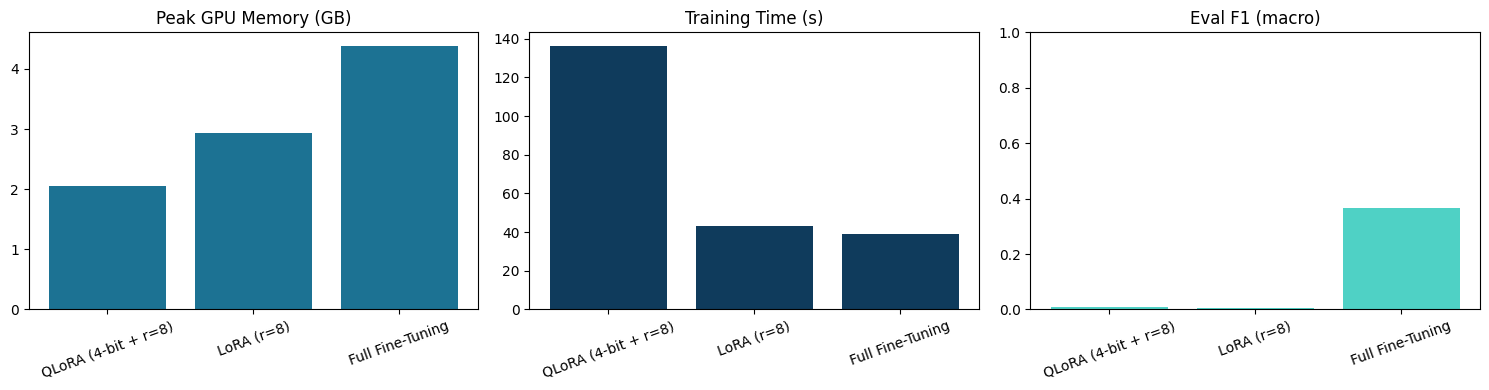

In [14]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(comparison_df["Strategy"], comparison_df["Peak GPU Mem (GB)"], color="#1C7293")
axes[0].set_title("Peak GPU Memory (GB)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(comparison_df["Strategy"], comparison_df["Train Time (s)"], color="#0F3B5C")
axes[1].set_title("Training Time (s)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(comparison_df["Strategy"], comparison_df["Eval F1 (macro)"], color="#4FD1C5")
axes[2].set_title("Eval F1 (macro)")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("./outputs/strategy_comparison.png", dpi=150)
plt.show()



**Discussion prompts (tie back to the lecture):**

- How close does LoRA's F1 land to full fine-tuning's, despite training under 1% of the
  parameters?
- Does QLoRA's peak memory actually beat LoRA's here? Why might the gap be small for a
  110M-parameter model — and why would you expect it to be large for a 7B+ model?
- If you were choosing a strategy for a **support ticket triage** system that needs
  weekly retraining as new intents appear, which would you pick, and why?



## 8. Packaging & Model Versioning

*(Maps to slide 11 — "Packaging & Registering Your Model")*

Pick **one** of the two paths below depending on your organization's tooling. Both cells
are optional — they require credentials this notebook doesn't have by default — but the
code shows exactly what you'd run in a real pipeline.



### Option A — Push to HuggingFace Hub

Requires a (free) HuggingFace account and an access token
([huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)).


In [ ]:

PUSH_TO_HUB = False  # flip to True and run `notebook_login()` first if you want to push

if PUSH_TO_HUB:
    from huggingface_hub import notebook_login
    notebook_login()

    # Merge the LoRA adapters into the base model for a single, self-contained artifact.
    # (Skip .merge_and_unload() if you'd rather ship a small adapter-only checkpoint.)
    best_model = lora_model.merge_and_unload()

    HUB_MODEL_ID = "your-username/banking77-intent-lora"  # <-- change this
    best_model.push_to_hub(HUB_MODEL_ID)
    tokenizer.push_to_hub(HUB_MODEL_ID)
    print(f"Pushed to https://huggingface.co/{HUB_MODEL_ID}")
else:
    print("PUSH_TO_HUB is False — set to True to actually push (requires your own HF account).")



### Option B — Register with MLflow Model Registry

Runs fully locally for this demo (no external server needed) using MLflow's file-based
tracking store.


In [15]:

USE_MLFLOW = False  # flip to True to log + register with MLflow

if USE_MLFLOW:
    !pip install -q mlflow
    import mlflow
    import mlflow.transformers

    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("nyp-nlp-peft-benchmark")

    with mlflow.start_run(run_name="lora-r8-final"):
        mlflow.log_params({
            "strategy": "LoRA",
            "rank": 8,
            "lora_alpha": 16,
            "base_model": MODEL_NAME,
        })
        mlflow.log_metrics({
            "eval_f1_macro": lora_results["eval_f1_macro"],
            "eval_accuracy": lora_results["eval_accuracy"],
            "peak_gpu_mem_gb": lora_results["peak_gpu_mem_gb"],
        })
        model_info = mlflow.transformers.log_model(
            transformers_model={"model": lora_model, "tokenizer": tokenizer},
            artifact_path="model",
            registered_model_name="banking77-intent-classifier",
        )
    print("Registered with MLflow — view with `mlflow ui` pointed at ./mlruns")
else:
    print("USE_MLFLOW is False — set to True to log + register locally with MLflow.")


USE_MLFLOW is False — set to True to log + register locally with MLflow.



## 9. Wrap-Up & Design Challenge

*(Maps to slide 13 — "Design Challenge: Match Strategy to Business Constraint")*

You now have a benchmarked comparison and a packaging path for a fine-tuned NLP model.
For your submission, pick **one** industry scenario below, and in 3-5 sentences justify
which fine-tuning strategy (full FT / LoRA / QLoRA) you would choose and why — referencing
your actual GPU memory, training time, and F1 numbers from Section 7.

| Scenario | Constraint |
|---|---|
| Support Ticket Triage | High volume, low latency budget, frequent new intents |
| Contract Analysis | Long documents, high accuracy bar, infrequent retraining |
| Clinical Notes Classification | Sensitive data, on-prem GPU constraints, compliance review |

**Checklist before you submit:**

- [ ] All three strategies (Full FT, LoRA, QLoRA) ran successfully and appear in `comparison_df`
- [ ] W&B dashboard shows three tracked runs under the `nyp-nlp-peft-benchmark` project
- [ ] Model packaged via HF Hub *or* MLflow (Section 8)
- [ ] One-paragraph strategy justification for your chosen business scenario
